# Deploy the hosted Copilot SDK agent on the shared 1:N multi account

The **"B" variant** of [`08-10`](../08-10-hosted-copilot-sdk-agent/08-10-00-hosted-copilot-sdk-agent.md). The container is the **same code as 08-10, kept here as this lab's own self-contained copy** (`src/github-copilot-invocations/`, plus its `data/`) - so 08-10b has **no dependency on 08-10**. Only the **topology and inference path** change:

- It is hosted on the existing shared **`aif-spoke-multi`** account (a new `copilot-sdk-project`), not a new dedicated account.
- Inference comes from the **APIM core gateway**, reached by pointing the Copilot SDK **directly at the gateway** with the subscription key in the `api-key` header - **not** through a Foundry project connection (that model-gateway path is prompt-agents-only). See the [overview](08-10b-00-hosted-copilot-sdk-agent-multi.md).
- The gateway-served model must be a **reasoning** model (`gpt-5-mini`); the default `gpt-4.1-mini` won't work because the Copilot CLI's Responses protocol carries encrypted reasoning content.

## Prerequisites

1. **`05-02` core gateway + `05-04` multi account already deployed** - so the repo `.env` has `GATEWAY_URL`, `MULTI_ACCOUNT`, and `MULTI_ACCOUNT_ENDPOINT`.
2. **`az login`** with **Owner** (or **Contributor + User Access Administrator**) on `rg-foundry-multi-{suffix}` **and** rights on `rg-foundry-core-{suffix}` (this lab mints a gateway subscription and deploys a reasoning model there).
3. **Reasoning-model quota** for `gpt-5-mini` GlobalStandard in the gateway region (`eastus2`) - the Copilot SDK requires a reasoning model.
4. The repo `uv` environment (`azure-ai-projects>=2.1.0`, `azure-identity`, `requests`). No local Docker needed (`az acr build` is server-side).

In [1]:
import json
import pathlib
import shutil
import subprocess

def sh(cmd, **kw):
    """Run a shell command, stream output, return CompletedProcess."""
    print(f"$ {cmd}")
    return subprocess.run(cmd, shell=True, check=False, **kw)

def _require(binary, install_hint):
    if shutil.which(binary) is None:
        raise AssertionError(
            f"`{binary}` is not on PATH. Install it and restart the kernel:\n  {install_hint}"
        )

_require("az", "Ubuntu: https://learn.microsoft.com/cli/azure/install-azure-cli-linux")

sh("az --version | head -1")

# Require az login
who = subprocess.run(
    "az account show --query '{name:name, id:id, tenant:tenantId, user:user.name}' -o jsonc",
    shell=True, capture_output=True, text=True,
)
if who.returncode != 0:
    raise AssertionError(
        "Not logged in to Azure CLI. Run `az login` in a terminal, then re-run this cell.\n"
        f"az stderr: {who.stderr.strip()}"
    )
print(who.stdout)


$ az --version | head -1


azure-cli                         2.85.0 *
{
  "id": "00000000-0000-0000-0000-000000000000",
  "name": "{subscription-name}",
  "tenant": "00000000-0000-0000-0000-000000000000",
  "user": "{user}@{tenant}.onmicrosoft.com"
}



## Step 1 - Load configuration from `.env` and derive names

In [2]:
import os, json, base64, hashlib, subprocess, time, pathlib, requests
from pathlib import Path
from dotenv import load_dotenv

repo_root = Path(subprocess.run(
    "git rev-parse --show-toplevel", shell=True, capture_output=True, text=True
).stdout.strip())
load_dotenv(repo_root / ".env", override=True)

SUBSCRIPTION_ID = subprocess.run(
    "az account show --query id -o tsv", shell=True, capture_output=True, text=True
).stdout.strip()
# Repo-wide multi-pattern suffix (matches 05-02 / 05-04 naming)
SUFFIX   = hashlib.sha256((SUBSCRIPTION_ID + "v2").encode()).hexdigest()[:6]
LOCATION = "eastus2"

MULTI_RG     = f"rg-foundry-multi-{SUFFIX}"
CORE_RG      = f"rg-foundry-core-{SUFFIX}"
APIM_NAME    = f"apim-foundry-{SUFFIX}"
CORE_ACCOUNT = f"aif-core-{SUFFIX}"          # gateway backend - where the reasoning model is deployed

# From .env (set by 05-02 core gateway + 05-04 multi account)
MULTI_ACCOUNT = os.environ["MULTI_ACCOUNT"]   # aif-spoke-multi-{suffix}
GATEWAY_URL   = os.environ["GATEWAY_URL"]     # https://apim-foundry-{suffix}.azure-api.net/openai

# This lab's names + config
PROJECT_NAME     = "copilot-sdk-project"
AGENT_NAME       = "github-copilot"
GATEWAY_SUB_NAME = "foundry-gateway-copilot-sdk"
# The Copilot SDK's Responses protocol carries encrypted reasoning content, which only a
# REASONING model accepts - the repo-wide gateway chat model (gpt-4.1-mini) does not. So this
# lab deploys and routes to a reasoning model on the gateway backend (Step 2).
AGENT_MODEL      = "gpt-5-mini"
AGENT_MODEL_VER  = "2025-08-07"
APIM_API_VERSION = "2025-03-01-preview"       # the api-version APIM serves the Responses API on

# Self-contained: this lab ships its own container source (src/) and demo data (data/);
# no dependency on the 08-10 lab.
SRC_DIR = pathlib.Path("src/github-copilot-invocations")
assert (SRC_DIR / "Dockerfile").is_file(), (
    "src/github-copilot-invocations/ not found - this lab is self-contained and needs its own source"
)

# Principal ID from the cached JWT (no Graph round-trip)
token = subprocess.run(
    "az account get-access-token --query accessToken -o tsv", shell=True, capture_output=True, text=True
).stdout.strip()
PRINCIPAL_ID = json.loads(base64.urlsafe_b64decode(token.split(".")[1] + "=="))["oid"]

print(f"Subscription:  {SUBSCRIPTION_ID}")
print(f"Suffix:        {SUFFIX}")
print(f"Multi RG:      {MULTI_RG}")
print(f"Shared acct:   {MULTI_ACCOUNT}")
print(f"Gateway:       {GATEWAY_URL}")
print(f"New project:   {PROJECT_NAME}")
print(f"Model (direct):{AGENT_MODEL}  (reasoning model on {CORE_ACCOUNT}, api-key auth)")
print(f"Agent name:    {AGENT_NAME}")
print(f"Principal ID:  {PRINCIPAL_ID}")

Subscription:  00000000-0000-0000-0000-000000000000
Suffix:        c2676f
Multi RG:      rg-foundry-multi-c2676f
Shared acct:   aif-spoke-multi-c2676f
Gateway:       https://apim-foundry-c2676f.azure-api.net/openai
New project:   copilot-sdk-project
Model (direct):gpt-5-mini  (reasoning model on aif-core-c2676f, api-key auth)
Agent name:    github-copilot
Principal ID:  00000000-0000-0000-0000-000000000000


## Step 2 - Gateway access: subscription + reasoning model

Two things on the **core gateway**, both isolated to this capability:

- **`foundry-gateway-copilot-sdk`** APIM subscription, scoped to the `openai` API, so this agent's inference quota is isolated from team traffic. Its key is what the container sends in the `api-key` header.
- A **reasoning model** (`gpt-5-mini`) on the gateway backend (`aif-core`). The Copilot SDK's Responses protocol carries *encrypted reasoning content*, which the default gateway chat model (`gpt-4.1-mini`) rejects. The model lives on the **core** account, not the multi account, so the `rg-foundry-multi` `deny-model-deployments` policy is untouched.

In [3]:
# Mint a dedicated APIM gateway subscription for this agent, scoped to the openai API, so its
# inference quota is isolated from team traffic (same pattern as foundry-gateway-iq / -obs).
apim_arm = (
    f"/subscriptions/{SUBSCRIPTION_ID}/resourceGroups/{CORE_RG}"
    f"/providers/Microsoft.ApiManagement/service/{APIM_NAME}"
)

put = subprocess.run(
    ["az", "rest", "--method", "PUT",
     "--uri", f"https://management.azure.com{apim_arm}/subscriptions/{GATEWAY_SUB_NAME}?api-version=2024-06-01-preview",
     "--body", json.dumps({"properties": {
         "displayName": "Copilot SDK Hosted Agent Gateway Access",
         "scope": f"{apim_arm}/apis/openai",
         "state": "active",
     }}),
     "--headers", "Content-Type=application/json"],
    capture_output=True, text=True,
)
assert put.returncode == 0, f"subscription create failed: {put.stderr}"

COPILOT_SDK_GATEWAY_KEY = subprocess.run(
    f'az rest --method POST'
    f' --uri "https://management.azure.com{apim_arm}/subscriptions/{GATEWAY_SUB_NAME}/listSecrets?api-version=2024-06-01-preview"'
    f' --query primaryKey -o tsv',
    shell=True, capture_output=True, text=True,
).stdout.strip()
assert COPILOT_SDK_GATEWAY_KEY, "could not read the subscription primary key"
print(f"Gateway subscription '{GATEWAY_SUB_NAME}' ready; key {COPILOT_SDK_GATEWAY_KEY[:2]}... (hidden)")

# Persist to .env for reuse
env_file = repo_root / ".env"
existing = {}
if env_file.exists():
    for line in env_file.read_text().splitlines():
        if "=" in line and not line.startswith("#"):
            k, _, v = line.partition("=")
            existing[k.strip()] = v.strip()
existing["COPILOT_SDK_GATEWAY_KEY"] = COPILOT_SDK_GATEWAY_KEY
env_file.write_text("\n".join(f"{k}={v}" for k, v in existing.items()) + "\n")
print("Saved COPILOT_SDK_GATEWAY_KEY to .env")

# Ensure a REASONING model is available on the gateway backend (aif-core). The Copilot SDK's
# Responses protocol carries encrypted reasoning content, which the default gateway chat model
# (gpt-4.1-mini) rejects. This deploys gpt-5-mini on the CORE account (rg-foundry-core), NOT the
# multi account, so the rg-foundry-multi deny-model-deployments policy is untouched. Idempotent.
print(f"\nEnsuring reasoning model '{AGENT_MODEL}' on the gateway backend {CORE_ACCOUNT} ...")
dep = subprocess.run(
    f'az cognitiveservices account deployment create -n "{CORE_ACCOUNT}" -g "{CORE_RG}" '
    f'--deployment-name "{AGENT_MODEL}" --model-name "{AGENT_MODEL}" --model-version "{AGENT_MODEL_VER}" '
    f'--model-format OpenAI --sku-name GlobalStandard --sku-capacity 100 -o none',
    shell=True, capture_output=True, text=True,
)
assert dep.returncode == 0, f"reasoning-model deploy failed: {dep.stderr}"
print(f"Reasoning model '{AGENT_MODEL}' ready on {CORE_ACCOUNT} (served via {GATEWAY_URL}).")

Gateway subscription 'foundry-gateway-copilot-sdk' ready; key 5f... (hidden)
Saved COPILOT_SDK_GATEWAY_KEY to .env

Ensuring reasoning model 'gpt-5-mini' on the gateway backend aif-core-c2676f ...
Reasoning model 'gpt-5-mini' ready on aif-core-c2676f (served via https://apim-foundry-c2676f.azure-api.net/openai).


## Step 3 - Provision the project and ACR

Adds `copilot-sdk-project` + an ACR to the existing shared account. **No connection and no local model deployment** - the container reaches the gateway directly (Step 6), and the reasoning model lives on the core account.

In [4]:
# Add copilot-sdk-project + ACR to the EXISTING shared account. No connection and no local model
# deployment - the container reaches the gateway directly (Step 6), so deny-model-deployments holds.
deploy = subprocess.run(
    ["az", "deployment", "group", "create",
     "-g", MULTI_RG,
     "--template-file", "infra/main.bicep",
     "-p", f"deployerPrincipalId={PRINCIPAL_ID}",
     "-p", f"multiAccountName={MULTI_ACCOUNT}",
     "-p", f"suffix={SUFFIX}",
     "-p", f"projectName={PROJECT_NAME}",
     "-p", f"location={LOCATION}",
     "-o", "table"],
    capture_output=True, text=True,
)
print(deploy.stdout)
if deploy.returncode != 0:
    raise RuntimeError(deploy.stderr)

Name    State      Timestamp                         Mode         ResourceGroup
------  ---------  --------------------------------  -----------  -----------------------
main    Succeeded  2026-09-17T15:52:54.429338+00:00  Incremental  rg-foundry-multi-c2676f



### Extract deployment outputs

In [5]:
r = subprocess.run(
    f'az deployment group show -g "{MULTI_RG}" -n main --query properties.outputs -o json',
    shell=True, capture_output=True, text=True,
)
assert r.returncode == 0, r.stderr
out = json.loads(r.stdout)

PROJECT_ENDPOINT = out["projectEndpoint"]["value"]
PROJECT_NAME     = out["projectName"]["value"]
ACR_NAME         = out["acrName"]["value"]
ACR_LOGIN_SERVER = out["acrLoginServer"]["value"]

print(f"Project endpoint: {PROJECT_ENDPOINT}")
print(f"Model (direct):   {AGENT_MODEL}  via  {GATEWAY_URL}  (api-key auth)")
print(f"ACR:              {ACR_LOGIN_SERVER}")

Project endpoint: https://aif-spoke-multi-c2676f.services.ai.azure.com/api/projects/copilot-sdk-project
Model (direct):   gpt-5-mini  via  https://apim-foundry-c2676f.azure-api.net/openai  (api-key auth)
ACR:              acrcopilotc2676f.azurecr.io


## Step 4 - Enable the hosted-agent capability host

One-time, account-level enablement on the shared `aif-spoke-multi` account. Idempotent (`409` = already enabled by an earlier lab).

In [6]:
# Enable the hosted-agent capability host on the SHARED account (one-time, idempotent).
# This is an account-level enablement, not a per-team workload; HTTP 409 means it already exists.
mgmt_token = subprocess.run(
    "az account get-access-token --resource https://management.azure.com/ --query accessToken -o tsv",
    shell=True, capture_output=True, text=True,
).stdout.strip()
headers = {"Content-Type": "application/json", "Authorization": f"Bearer {mgmt_token}"}

cap_url = (
    f"https://management.azure.com/subscriptions/{SUBSCRIPTION_ID}"
    f"/resourceGroups/{MULTI_RG}"
    f"/providers/Microsoft.CognitiveServices/accounts/{MULTI_ACCOUNT}"
    f"/capabilityHosts/agents?api-version=2025-10-01-preview"
)
resp = requests.put(
    cap_url, headers=headers,
    json={"properties": {"capabilityHostKind": "Agents", "enablePublicHostingEnvironment": True}},
)
print(f"Capability host PUT: {resp.status_code}")
if resp.status_code not in (200, 201, 409):
    print(resp.text)

print("Waiting for capability host (2-5 min)...")
for i in range(30):
    g = requests.get(cap_url, headers=headers)
    if g.status_code == 200:
        state = g.json().get("properties", {}).get("provisioningState", "Unknown")
        print(f"  [{i*10}s] {state}")
        if state == "Succeeded":
            print("Capability host ready."); break
        if state == "Failed":
            print("Capability host provisioning failed."); print(g.json()); break
    time.sleep(10)
else:
    print("Timeout waiting for capability host.")

Capability host PUT: 201
Waiting for capability host (2-5 min)...
  [0s] Succeeded
Capability host ready.


## Step 5 - Build the agent image

Builds the **08-10 container** from the sibling lab's source - this variant changes topology, not the agent.

In [7]:
# Build this lab's own Copilot SDK container image (self-contained - no dependency on 08-10).
print(f"Building {AGENT_NAME}:latest from {SRC_DIR} ...")
sh(
    f'az acr build --registry "{ACR_NAME}" '
    f'--image "{AGENT_NAME}:latest" '
    f'--platform linux/amd64 '
    f'"{SRC_DIR}/"'
)

Building github-copilot:latest from src/github-copilot-invocations ...
$ az acr build --registry "acrcopilotc2676f" --image "github-copilot:latest" --platform linux/amd64 "src/github-copilot-invocations/"


2026/09/17 15:53:22 Downloading source code...
2026/09/17 15:53:24 Finished downloading source code
2026/09/17 15:53:24 Using acb_vol_00000000-0000-0000-0000-000000000000 as the home volume
2026/09/17 15:53:24 Setting up Docker configuration...
2026/09/17 15:53:25 Successfully set up Docker configuration
2026/09/17 15:53:25 Logging in to registry: acrcopilotc2676f.azurecr.io
2026/09/17 15:53:26 Successfully logged into acrcopilotc2676f.azurecr.io
2026/09/17 15:53:26 Executing step ID: build. Timeout(sec): 28800, Working directory: '', Network: ''
2026/09/17 15:53:26 Scanning for dependencies...
2026/09/17 15:53:27 Successfully scanned dependencies
2026/09/17 15:53:27 Launching container with name: build

Step 1/7 : FROM mcr.microsoft.com/devcontainers/python:3.12-bookworm
3.12-bookworm: Pulling from devcontainers/python
abf56b2f8724: Pulling fs layer
08457856946d: Pulling fs layer
8cab6ce149c2: Pulling fs layer
01a6a9ffe665: Pulling fs layer
9fc491314404: Pulling fs layer
cbbcd353f76c:

CompletedProcess(args='az acr build --registry "acrcopilotc2676f" --image "github-copilot:latest" --platform linux/amd64 "src/github-copilot-invocations/"', returncode=0)

## Step 6 - Register the hosted agent

The container points its Copilot SDK provider **directly at the gateway**: `APIM_BASE_URL` (the APIM `/openai` endpoint) + `APIM_KEY` (the subscription key, sent in the `api-key` header) + a **bare reasoning model** in `AZURE_AI_MODEL_DEPLOYMENT_NAME`. `main.py`'s `_byok_provider()` switches to this APIM-direct mode whenever `APIM_BASE_URL` + `APIM_KEY` are set; otherwise it falls back to the Foundry-project endpoint (the standalone 08-10 path).

In [8]:
from azure.ai.projects import AIProjectClient
from azure.ai.projects.models import HostedAgentDefinition, ProtocolVersionRecord, AgentProtocol
from azure.identity import DefaultAzureCredential
from azure.core.rest import HttpRequest

client = AIProjectClient(endpoint=PROJECT_ENDPOINT, credential=DefaultAzureCredential(), allow_preview=True)
CONTAINER_IMAGE = f"{ACR_LOGIN_SERVER}/{AGENT_NAME}:latest"

# APIM-direct env: the container points its Copilot SDK provider straight at the gateway
# (APIM_BASE_URL) and authenticates with the subscription key (APIM_KEY) in the api-key header.
# main.py's _byok_provider() switches to this mode whenever APIM_BASE_URL + APIM_KEY are set.
APIM_ENV = {
    "AZURE_AI_PROJECT_ENDPOINT":      PROJECT_ENDPOINT,
    "AZURE_AI_MODEL_DEPLOYMENT_NAME": AGENT_MODEL,            # bare deployment name (reasoning model)
    "APIM_BASE_URL":                  GATEWAY_URL,            # https://apim-...azure-api.net/openai
    "APIM_KEY":                       COPILOT_SDK_GATEWAY_KEY,
    "APIM_API_VERSION":               APIM_API_VERSION,
}

# Bootstrap registration - surfaces the per-version AgentIdentity client_id we pin in Step 6.5.
agent = client.agents.create_version(
    agent_name=AGENT_NAME,
    definition=HostedAgentDefinition(
        container_protocol_versions=[ProtocolVersionRecord(protocol=AgentProtocol.INVOCATIONS, version="1.0.0")],
        cpu="2", memory="4Gi",
        image=CONTAINER_IMAGE,
        environment_variables=APIM_ENV,
    ),
)
print(f"Bootstrap version: {agent.name} v{agent.version}")

Bootstrap version: github-copilot v13


### Step 6.5 - Re-register with `AZURE_CLIENT_ID` pinned to the AgentIdentity

In [9]:
bootstrap_version = agent.version  # capture before reassignment
v_meta = json.loads(
    client.send_request(HttpRequest("GET", f"/agents/{AGENT_NAME}/versions/{agent.version}?api-version=v1")).text()
)
AGENT_IDENTITY_CLIENT_ID = v_meta["instance_identity"]["client_id"]
print(f"Pinning AZURE_CLIENT_ID = {AGENT_IDENTITY_CLIENT_ID} (AgentIdentity)")

agent = client.agents.create_version(
    agent_name=AGENT_NAME,
    definition=HostedAgentDefinition(
        container_protocol_versions=[ProtocolVersionRecord(protocol=AgentProtocol.INVOCATIONS, version="1.0.0")],
        cpu="2", memory="4Gi",
        image=CONTAINER_IMAGE,
        environment_variables={**APIM_ENV, "AZURE_CLIENT_ID": AGENT_IDENTITY_CLIENT_ID},
    ),
)
print(f"Active version: {agent.name} v{agent.version}")
print(f"Image:          {CONTAINER_IMAGE}")

client.agents.delete_version(AGENT_NAME, agent_version=bootstrap_version)
print(f"Deleted bootstrap v{bootstrap_version}; single active version v{agent.version}")

Pinning AZURE_CLIENT_ID = 00000000-0000-0000-0000-000000000000 (AgentIdentity)
Active version: github-copilot v14
Image:          acrcopilotc2676f.azurecr.io/github-copilot:latest
Deleted bootstrap v13; single active version v14


## Step 7 - Grant runtime roles to the per-agent identity

**Two grants only** - `AcrPull` + `Foundry User`. No account-scoped OpenAI role: the connection's key pays for inference (contrast 08-10 standalone).

In [10]:
# Re-read the AgentIdentity principal from the active version.
v = json.loads(
    client.send_request(HttpRequest("GET", f"/agents/{AGENT_NAME}/versions/{agent.version}?api-version=v1")).text()
)
AGENT_IDENTITY_PRINCIPAL_ID = v["instance_identity"]["principal_id"]
print(f"AgentIdentity principal: {AGENT_IDENTITY_PRINCIPAL_ID}")

acr_id = subprocess.check_output(f"az acr show -n {ACR_NAME} --query id -o tsv", shell=True, text=True).strip()
project_id = (
    f"/subscriptions/{SUBSCRIPTION_ID}/resourceGroups/{MULTI_RG}"
    f"/providers/Microsoft.CognitiveServices/accounts/{MULTI_ACCOUNT}/projects/{PROJECT_NAME}"
)

FOUNDRY_USER = "53ca6127-db72-4b80-b1b0-d745d6d5456d"   # general Foundry data plane
# Only two grants are needed:
#   AcrPull      -> pull the container image
#   Foundry User -> invoke the agent endpoint / platform data plane
# Inference is paid for by the gateway subscription key the container sends DIRECTLY to APIM
# (api-key header) - so, unlike 08-10 standalone (which deploys a LOCAL model reached by the
# agent's managed identity), NO account-scoped Cognitive Services OpenAI User grant is needed.
grants = [("AcrPull", acr_id), (FOUNDRY_USER, project_id)]
for role, scope in grants:
    r = subprocess.run(
        f"az role assignment create --assignee-object-id {AGENT_IDENTITY_PRINCIPAL_ID} "
        f"--assignee-principal-type ServicePrincipal --role '{role}' --scope '{scope}'",
        shell=True, capture_output=True, text=True,
    )
    if r.returncode == 0:
        print(f"  granted: {role}")
    elif "already exist" in r.stderr.lower():
        print(f"  already granted: {role}")
    else:
        print(f"  failed:  {role} - {r.stderr.strip()[:200]}")

print("\nWaiting 90s for RBAC + container cold start to settle...")
time.sleep(90)
print("Done. Continue to Step 8.")

AgentIdentity principal: 00000000-0000-0000-0000-000000000000
  granted: AcrPull
  granted: 53ca6127-db72-4b80-b1b0-d745d6d5456d

Waiting 90s for RBAC + container cold start to settle...
Done. Continue to Step 8.


## Step 8 - Smoke-test the agent

The first successful turn is the proof that the container can **reach the APIM gateway directly** (hosted-agent egress) and **authenticate with the `api-key` header** - inference comes straight from the gateway's `gpt-5-mini`, with no Foundry connection in the path.

In [11]:
import sys
import time
import requests
from IPython.display import Markdown, display
import re


def _md_fix(text):
    """Render agent replies as clean Markdown: strip a wrapping code fence and
    guarantee a blank line before a Markdown table. The reasoning model often glues
    a narration sentence directly onto the table header (``...table.| col |``), and
    without a preceding blank line Markdown shows the raw pipes instead of a table."""
    text = text.strip()
    fence = re.match(r"^```(?:markdown|md)?\s*\n(.*)\n```$", text, re.S)
    if fence:
        text = fence.group(1)
    lines = text.split("\n")
    sep = re.compile(r"^\s*\|?[\s:|\-]*-[\s:|\-]*\|?\s*$")  # a |---|---| separator row
    out = []
    for i, ln in enumerate(lines):
        is_header = (i + 1 < len(lines) and "|" in ln
                     and "|" in lines[i + 1] and sep.match(lines[i + 1]))
        if is_header:
            pre, tbl = ln[:ln.find("|")].rstrip(), ln[ln.find("|"):]
            if pre:                      # prose glued before the table -> split it off
                out += [pre, "", tbl]
            else:                        # header starts the line -> just ensure a blank line above
                if out and out[-1].strip():
                    out.append("")
                out.append(ln)
        else:
            out.append(ln)
    return "\n".join(out)

API_VERSION = "v1"

def _bearer():
    return DefaultAzureCredential().get_token("https://ai.azure.com/.default").token

def invoke(input_text, session_id=None, stream=True, render=False, retries=5, retry_delay=30):
    """POST to the agent. Streams SSE assistant deltas; returns (text, session_id).

    With render=True the reply is rendered live as Markdown (so tables become real
    tables) instead of raw streamed text - use it for the analytics prompts below.

    Retries on 5xx and on mid-stream `error` events (the container warming up,
    RBAC propagating, or being recycled mid-turn). Default budget is 5 retries x 30s = 150s, enough to cover
    typical RBAC propagation + container cold start. On final failure, prints
    the response body before raising.
    """
    base = (
        f"{PROJECT_ENDPOINT}/agents/{AGENT_NAME}/endpoint/protocols/"
        f"invocations?api-version={API_VERSION}"
    )
    url = base if session_id is None else f"{base}&agent_session_id={session_id}"
    body = json.dumps({"input": input_text})
    last_status, last_body = None, None
    md_handle = display(Markdown(""), display_id=True) if render else None
    for attempt in range(1, retries + 1):
        headers = {
            "Authorization": f"Bearer {_bearer()}",
            "Foundry-Features": "HostedAgents=V1Preview",
            "Content-Type": "application/json",
        }
        resp = requests.post(url, headers=headers, data=body, stream=True)
        if resp.status_code >= 500 and attempt < retries:
            # Read body now (before stream is consumed) so we can show it if needed.
            last_status, last_body = resp.status_code, resp.text[:500]
            print(
                f"[invoke] {resp.status_code} from server (attempt {attempt}/{retries}); "
                f"retrying in {retry_delay}s..."
            )
            time.sleep(retry_delay)
            continue
        if not resp.ok:
            print(f"[invoke] HTTP {resp.status_code}")
            print(f"[invoke] body: {resp.text[:1500]}")
            resp.raise_for_status()
        # Success - stream SSE
        chunks, out_sid, stream_error = [], session_id, None
        for raw in resp.iter_lines(decode_unicode=True):
            if not raw or not raw.startswith("data:"):
                continue
            try:
                event = json.loads(raw[5:].strip())
            except json.JSONDecodeError:
                continue
            etype = event.get("type")
            if etype == "assistant.message_delta":
                delta = event.get("data", {}).get("deltaContent") or ""
                chunks.append(delta)
                if render:
                    if "\n" in delta:
                        md_handle.update(Markdown(_md_fix("".join(chunks))))
                elif stream:
                    sys.stdout.write(delta)
                    sys.stdout.flush()
            elif etype == "error":
                stream_error = event.get("message")
                break
            elif "session_id" in event and "invocation_id" in event:
                out_sid = event["session_id"]
        # A mid-stream error (container recycled, gateway reset, etc.) means the turn
        # produced no usable answer: retry if attempts remain, else fail loudly.
        if stream_error:
            if attempt < retries:
                last_status, last_body = "stream-error", stream_error[:500]
                print(f"\n[invoke] agent error mid-stream (attempt {attempt}/{retries}); retrying in {retry_delay}s...")
                time.sleep(retry_delay)
                continue
            print(f"\n[agent error] {stream_error}", file=sys.stderr)
            raise RuntimeError(f"Agent invocation failed after {retries} attempts (mid-stream error): {stream_error[:200]}")
        if render:
            md_handle.update(Markdown(_md_fix("".join(chunks))))
        elif stream:
            print()
        return "".join(chunks), out_sid
    # Exhausted retries
    print(f"[invoke] exhausted {retries} retries. Last status: {last_status}")
    print(f"[invoke] last body: {last_body}")
    raise RuntimeError(f"Agent invocation failed after {retries} retries (status={last_status}).")

def upload_session_file(session_id, local_path, target_path):
    """PUT a local file into the session sandbox."""
    url = (
        f"{PROJECT_ENDPOINT}/agents/{AGENT_NAME}/endpoint/sessions/{session_id}"
        f"/files/content?api-version={API_VERSION}&path={target_path}"
    )
    headers = {
        "Authorization": f"Bearer {_bearer()}",
        "Foundry-Features": "HostedAgents=V1Preview",
        "Content-Type": "application/octet-stream",
    }
    with open(local_path, "rb") as f:
        r = requests.put(url, headers=headers, data=f.read())
    r.raise_for_status()
    return r


def download_session_file(session_id, remote_path, local_path):
    """GET a file out of the session sandbox (the read counterpart to upload_session_file)."""
    url = (
        f"{PROJECT_ENDPOINT}/agents/{AGENT_NAME}/endpoint/sessions/{session_id}"
        f"/files/content?api-version={API_VERSION}&path={remote_path}"
    )
    headers = {
        "Authorization": f"Bearer {_bearer()}",
        "Foundry-Features": "HostedAgents=V1Preview",
    }
    r = requests.get(url, headers=headers)
    r.raise_for_status()
    with open(local_path, "wb") as f:
        f.write(r.content)
    return len(r.content)


def show_agent_status():
    """Pretty-print the current agent version status from the project data plane."""
    from azure.core.rest import HttpRequest
    raw = client.send_request(
        HttpRequest("GET", f"/agents/{AGENT_NAME}/versions/{agent.version}?api-version={API_VERSION}")
    ).text()
    info = json.loads(raw)
    # Surface the bits that actually matter for "is it healthy"
    summary = {
        "name":              info.get("name"),
        "version":           info.get("version"),
        "status":            info.get("status"),
        "provisioning_state": info.get("provisioning_state"),
        "image":             info.get("definition", {}).get("image"),
        "instance_identity": info.get("instance_identity"),
        "endpoint":          info.get("endpoint"),
        "last_error":        info.get("last_error") or info.get("error"),
    }
    print(json.dumps(summary, indent=2, default=str))
    return summary  # redacted: never return env vars (they hold APIM_KEY)

print("Helpers defined: invoke(), upload_session_file(), download_session_file(), show_agent_status().")


Helpers defined: invoke(), upload_session_file(), download_session_file(), show_agent_status().


In [12]:
# Smoke test 1 - general capability question.
invoke("What can you help me with? Be brief.")


I can help with software engineering tasks in this workspace. Examples:
- Edit, run, and test code; fix bugs and implement features
- Run shell commands, builds, and package installs
- Create and update files, commits, and PR-ready changes
- Add or run tests and linters; debug failures
- Search and analyze the codebase; propose implementation plans
- Generate docs, API designs, and examples
- Track work with todos (uses built-in SQL)

Limitations: I won't expose secrets or perform unsafe actions. Tell me the repo task and I'll get to work.


("I can help with software engineering tasks in this workspace. Examples:\n- Edit, run, and test code; fix bugs and implement features\n- Run shell commands, builds, and package installs\n- Create and update files, commits, and PR-ready changes\n- Add or run tests and linters; debug failures\n- Search and analyze the codebase; propose implementation plans\n- Generate docs, API designs, and examples\n- Track work with todos (uses built-in SQL)\n\nLimitations: I won't expose secrets or perform unsafe actions. Tell me the repo task and I'll get to work.",
 '{session-id}')

In [13]:
# Smoke test 2 - exercises the agent's built-in shell/Python tools (no CSV needed).
invoke("Use your shell tools to print the current date and your Python version, then summarise in one line.")

Running shell commands to print the system date and the Python interpreter version for a concise verification. Calling report_intent alongside the bash command as required.2026-09-17T15:58:04+00:00
Python 3.12.14

Summary: System date is 2026-09-17T15:58:04+00:00 and Python version is Python 3.12.14.


('Running shell commands to print the system date and the Python interpreter version for a concise verification. Calling report_intent alongside the bash command as required.2026-09-17T15:58:04+00:00\nPython 3.12.14\n\nSummary: System date is 2026-09-17T15:58:04+00:00 and Python version is Python 3.12.14.',
 '{session-id}')

### Troubleshooting cold starts / model resolution

Run this if a smoke test keeps returning 500, or if a turn errors. Check, in order: (1) `gpt-5-mini` is deployed on the gateway backend (`aif-core`) and reachable via the gateway; (2) the agent version has `APIM_BASE_URL` + `APIM_KEY` set and the gateway subscription key is active; (3) the AgentIdentity has AcrPull + Foundry User (Step 7). A `400 ... encrypted content is not supported` error means the model isn't a reasoning model.

In [14]:
# Run this if a smoke test keeps returning 500 after invoke() exhausts its retries.
show_agent_status()

{
  "name": "github-copilot",
  "version": "14",
  "status": "active",
  "provisioning_state": null,
  "image": "acrcopilotc2676f.azurecr.io/github-copilot@sha256:c84f3f8844f6d8c3464b87fc73cd0602f9607b018178647ef75958c51b5ede27",
  "instance_identity": {
    "principal_id": "00000000-0000-0000-0000-000000000000",
    "client_id": "00000000-0000-0000-0000-000000000000"
  },
  "endpoint": null,
  "last_error": null
}


{'name': 'github-copilot',
 'version': '14',
 'status': 'active',
 'provisioning_state': None,
 'image': 'acrcopilotc2676f.azurecr.io/github-copilot@sha256:c84f3f8844f6d8c3464b87fc73cd0602f9607b018178647ef75958c51b5ede27',
 'instance_identity': {'principal_id': '00000000-0000-0000-0000-000000000000',
  'client_id': '00000000-0000-0000-0000-000000000000'},
 'endpoint': None,
 'last_error': None}

## Step 9 - CSV analytics: M365 license cleanup demo

The same workload as 08-10, now served by the APIM-fronted `gpt-4.1-mini`. Data is reused from the sibling lab.

### 9.1 - Warm-up: create a session and capture its `session_id`

In [15]:
print("--- warm-up ---")
_, SESSION_ID = invoke(
    "We're about to analyse an M365 license CSV. Reply with one word: ready."
)
print(f"\nsession_id = {SESSION_ID}\n")


--- warm-up ---
ready

session_id = {session-id}



### 9.2 - Upload the CSV and the cost/department reference into the session sandbox

In [16]:
import os
os.makedirs("data", exist_ok=True)   # chart downloads land here

# Demo data lives in this lab's own data/ (self-contained)
CSV_LOCAL  = "data/m365-licenses.csv"
CSV_REMOTE = "m365-licenses.csv"
REF_LOCAL  = "data/m365-reference.json"
REF_REMOTE = "m365-reference.json"

for local, remote in [(CSV_LOCAL, CSV_REMOTE), (REF_LOCAL, REF_REMOTE)]:
    upload_session_file(SESSION_ID, local, remote)
    print(f"Uploaded {local} ({pathlib.Path(local).stat().st_size} bytes) -> session {SESSION_ID} as {remote}")
print()

print("--- agent confirms it can see the files ---")
_ = invoke(
    f"Two files were just uploaded to your session: the data `{CSV_REMOTE}` and the reference `{REF_REMOTE}`. "
    "Locate them (try `find $HOME /files -name '*.csv' -o -name '*.json' 2>/dev/null`), run `head -2` on the CSV, "
    "and print the top-level keys of the JSON. Reply with the two paths and the CSV header line. Be terse.",
    session_id=SESSION_ID,
)

Uploaded data/m365-licenses.csv (10303 bytes) -> session {session-id} as m365-licenses.csv
Uploaded data/m365-reference.json (363 bytes) -> session {session-id} as m365-reference.json

--- agent confirms it can see the files ---
/home/session/m365-licenses.csv
/home/session/m365-reference.json
UserPrincipalName,sAMAccountName,DisplayName,Ext.5,Ext.6,Ext.3,whenCreated,LastSignInDateTime,AccountEnabled


### 9.3 - Prompt 1: license count per SKU

In [17]:
print("\n=== Q1: License count per SKU ===")
_ = invoke(
    f"Using the CSV `{CSV_REMOTE}`, return a markdown table of users per license SKU (column `Ext.5`), "
    "sorted by count descending. Columns: License SKU, User count. No commentary, table only.",
    session_id=SESSION_ID,
    render=True,
)



=== Q1: License count per SKU ===


| License SKU | User count |
|---|---:|
| SPE_E3 | 33 |
| SPE_E5 | 32 |
| ENTERPRISEPACK | 18 |
| STANDARDPACK | 10 |
| M365_F1 | 4 |
| M365_F3 | 3 |

### 9.4 - Prompt 2: stale SPE_E5 holders (90+ days inactive)

In [18]:
print("\n=== Q2: SPE_E5 holders inactive 90+ days ===")
_ = invoke(
    f"Using `{CSV_REMOTE}`, list every user whose `Ext.5` is `SPE_E5` AND `AccountEnabled` is `TRUE` "
    "AND `LastSignInDateTime` is non-empty AND older than 90 days from today (2026-05-28). "
    "Return a markdown table: UserPrincipalName, DisplayName, LastSignInDateTime, days_since_signin, Ext.6. "
    "Sort by days_since_signin descending. End with a one-line summary of total count.",
    session_id=SESSION_ID,
    render=True,
)



=== Q2: SPE_E5 holders inactive 90+ days ===


| UserPrincipalName | DisplayName | LastSignInDateTime | days_since_signin | Ext.6 |
|---|---|---|---:|---|
| sandra.hall@contoso.com | Sandra Hall | 2025-06-14T07:00:00Z | 348 | 3 |
| david.robinson@contoso.com | David Robinson | 2025-10-14T08:00:00Z | 226 | 1 |
| carol.adams@contoso.com | Carol Adams | 2025-10-21T18:00:00Z | 219 | 1 |
| stephanie.jones@contoso.com | Stephanie Jones | 2025-11-18T02:00:00Z | 191 | 4 |
| melissa.davis@contoso.com | Melissa Davis | 2026-01-01T06:00:00Z | 147 | 7 |
| joshua.taylor@contoso.com | Joshua Taylor | 2026-02-15T03:00:00Z | 102 | 1 |

Total: 6 users

### 9.5 - Prompt 3: disabled accounts still holding a license

In [19]:
print("\n=== Q3: Disabled accounts still licensed ===")
_ = invoke(
    f"Using `{CSV_REMOTE}`, list every row where `AccountEnabled` is `FALSE`. "
    "Return a markdown table: UserPrincipalName, Ext.5 (license SKU), Ext.6 (department code), whenCreated. "
    "End with: 'Cleanup candidates: <count>'.",
    session_id=SESSION_ID,
    render=True,
)



=== Q3: Disabled accounts still licensed ===


Running a CSV filter to extract rows with AccountEnabled FALSE and print the requested markdown table.

| UserPrincipalName | Ext.5 | Ext.6 | whenCreated |
|---|---|---:|---|
| deborah.mitchell@contoso.com | SPE_E5 | 5 | 2025-02-24 |
| elizabeth.green@contoso.com | ENTERPRISEPACK | 2 | 2023-01-16 |
| karen.carter@contoso.com | SPE_E5 | 3 | 2021-09-13 |
| liam.adams@contoso.com | SPE_E3 | 5 | 2023-04-12 |
| noah.smith@contoso.com | SPE_E3 | 3 | 2021-12-24 |

Cleanup candidates: 5

### 9.6 - Prompt 4: monthly cost per department

In [20]:
print("\n=== Q4: Monthly M365 cost per department ===")
_ = invoke(
    f"Using `{CSV_REMOTE}` joined to the costs and department names in `{REF_REMOTE}`, "
    "compute total monthly license spend per department. Return a markdown table sorted by "
    "total cost descending: Department, User count, Monthly cost (USD). End with the grand total.",
    session_id=SESSION_ID,
    render=True,
)



=== Q4: Monthly M365 cost per department ===


| Department | User count | Monthly cost (USD) |
|---|---:|---:|
| Engineering | 21 | $1,066.00 |
| Sales | 17 | $610.00 |
| IT | 9 | $492.00 |
| Finance | 14 | $473.00 |
| Marketing | 11 | $360.00 |
| HR | 10 | $277.00 |
| Operations | 15 | $165.00 |
| Legal | 3 | $116.00 |

Grand total: $3,559.00 (100 users)

### 9.7 - Prompt 5: optimisation recommendation (reclaim plan)

In [21]:
print("\n=== Q5: Reclaim plan - who to deprovision and how much we'd save ===")
_ = invoke(
    f"Using `{CSV_REMOTE}`, find every reclaim candidate per your reclaim rules (today is 2026-05-28), "
    f"costing each license from `{REF_REMOTE}`. "
    "Output exactly:\n"
    "1. A one-line summary: 'Total reclaimable: <N> users, <amount> USD/month'.\n"
    "2. A markdown table sorted by Monthly savings descending: "
    "UserPrincipalName, Reason, License (Ext.5), Monthly savings (USD).\n"
    "Be precise about the math.",
    session_id=SESSION_ID,
    render=True,
)



=== Q5: Reclaim plan - who to deprovision and how much we'd save ===


Total reclaimable: 20 users, $761.25 USD/month

| UserPrincipalName | Reason | License (Ext.5) | Monthly savings (USD) |
|---|---|---|---:|
| carol.adams@contoso.com | Inactive >90 days (219 days) | SPE_E5 | $57.00 |
| david.robinson@contoso.com | Inactive >90 days (226 days) | SPE_E5 | $57.00 |
| deborah.mitchell@contoso.com | Disabled account | SPE_E5 | $57.00 |
| joshua.taylor@contoso.com | Inactive >90 days (102 days) | SPE_E5 | $57.00 |
| karen.carter@contoso.com | Disabled account | SPE_E5 | $57.00 |
| melissa.davis@contoso.com | Inactive >90 days (147 days) | SPE_E5 | $57.00 |
| sandra.hall@contoso.com | Inactive >90 days (348 days) | SPE_E5 | $57.00 |
| stephanie.jones@contoso.com | Inactive >90 days (191 days) | SPE_E5 | $57.00 |
| liam.adams@contoso.com | Disabled account | SPE_E3 | $36.00 |
| matthew.hill@contoso.com | Inactive >90 days (97 days) | SPE_E3 | $36.00 |
| noah.smith@contoso.com | Disabled account | SPE_E3 | $36.00 |
| richard.martinez@contoso.com | Inactive >90 days (92 days) | SPE_E3 | $36.00 |
| robert.wright@contoso.com | Inactive >90 days (217 days) | SPE_E3 | $36.00 |
| sofia.campbell@contoso.com | Inactive >90 days (234 days) | SPE_E3 | $36.00 |
| elizabeth.green@contoso.com | Disabled account | ENTERPRISEPACK | $23.00 |
| liam.gonzalez@contoso.com | Inactive >90 days (164 days) | ENTERPRISEPACK | $23.00 |
| patricia.hernandez@contoso.com | Inactive >90 days (316 days) | ENTERPRISEPACK | $23.00 |
| william.robinson@contoso.com | Inactive >90 days (350 days) | STANDARDPACK | $10.00 |
| daniel.wilson@contoso.com | Inactive >90 days (300 days) | M365_F3 | $8.00 |
| lisa.wilson@contoso.com | Inactive >90 days (118 days) | M365_F1 | $2.25 |

### 9.8 - Visualise: chart cost by department, then download it


=== Q6: render a cost-by-department chart and save it to the sandbox ===
Downloaded license_cost_by_department.png -> data/license_cost_by_department.png (47969 bytes)


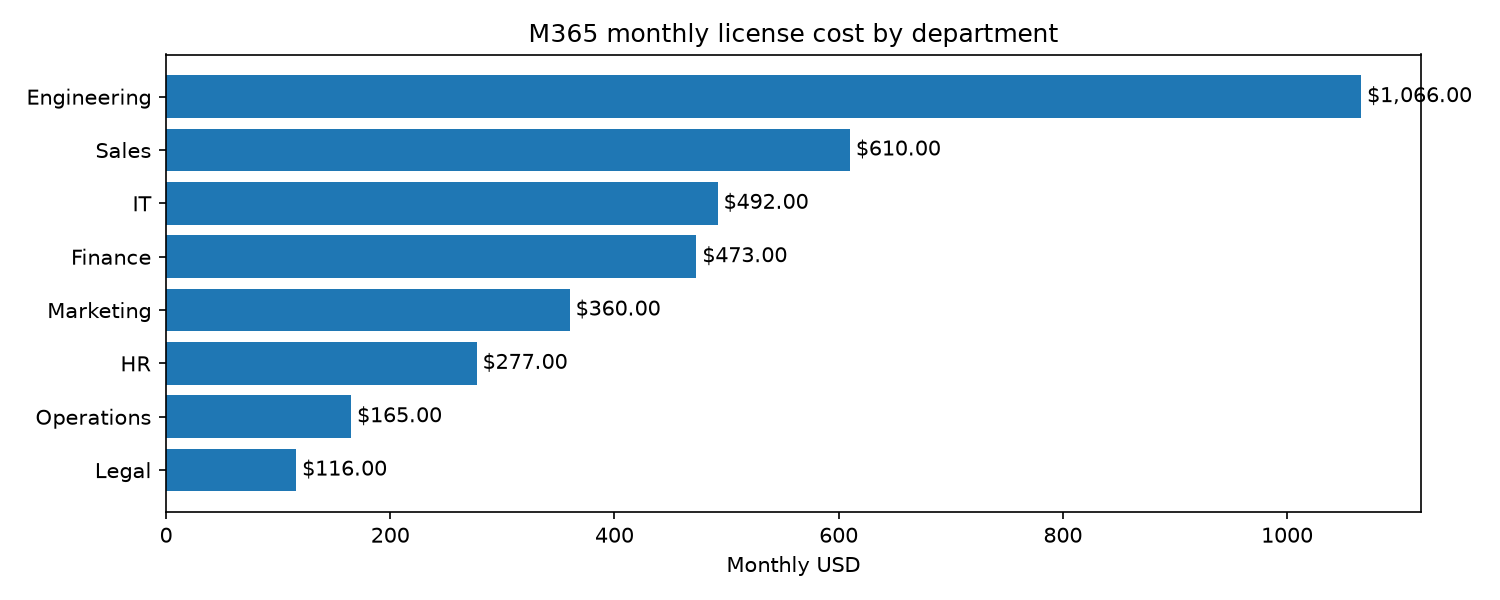

In [22]:
import re
from IPython.display import Image, SVG, display

print("\n=== Q6: render a cost-by-department chart and save it to the sandbox ===")
chart_answer, _ = invoke(
    f"Using `{CSV_REMOTE}` joined to `{REF_REMOTE}`, compute total monthly license spend per department "
    "(department names come from the reference). Render a horizontal bar chart: department on the y-axis, "
    "monthly USD on the x-axis, bars sorted by cost descending, each bar labelled with its dollar value, "
    "title 'M365 monthly license cost by department'. "
    "Save the chart into the SAME directory as the uploaded CSV. "
    "Prefer matplotlib with a non-interactive backend (Agg); if it is not importable, pip install it into your "
    "session shell; if you have no network to install packages, hand-write a self-contained SVG bar chart instead. "
    "Name the file `license_cost_by_department.png` (matplotlib) or `license_cost_by_department.svg` (SVG fallback). "
    "After saving, reply with EXACTLY one line and nothing else: `CHART_FILE: <bare filename, no directory>`.",
    session_id=SESSION_ID,
    stream=False,   # we only need the CHART_FILE line - don't dump the narration
)

m = re.search(r"CHART_FILE:\s*`?([^\s`]+)", chart_answer)
if not m:
    raise RuntimeError(f"Agent did not report a CHART_FILE line. Full reply:\n{chart_answer}")
# The files API serves paths relative to the session root, so download by bare filename
# (the agent sometimes reports an absolute path like /home/session/<file>, which 404s).
chart_remote = m.group(1).rsplit("/", 1)[-1]
chart_local = f"data/{chart_remote}"

try:
    n = download_session_file(SESSION_ID, chart_remote, chart_local)
    print(f"Downloaded {chart_remote} -> {chart_local} ({n} bytes)")
    display(SVG(filename=chart_local) if chart_remote.endswith(".svg") else Image(filename=chart_local))
except Exception as exc:
    # Some platform builds don't serve agent-written files through the file API.
    # Fall back to having the agent return the chart inline as SVG (always works over SSE).
    print(f"[download] could not GET {chart_remote} ({exc}); asking the agent to inline the SVG instead...")
    svg_answer, _ = invoke(
        "Re-render that same department-cost bar chart as one self-contained SVG and output ONLY the raw "
        "SVG markup, starting with <svg and ending with </svg> - no code fences, no commentary.",
        session_id=SESSION_ID,
        stream=False,   # render the SVG below; don't print the raw markup
    )
    sm = re.search(r"<svg.*?</svg>", svg_answer, re.S)
    if not sm:
        raise RuntimeError(f"No inline SVG in fallback reply:\n{svg_answer[:600]}")
    chart_local = "data/license_cost_by_department.svg"
    with open(chart_local, "w", encoding="utf-8") as f:
        f.write(sm.group(0))
    print(f"Saved inline SVG -> {chart_local}")
    display(SVG(data=sm.group(0)))

## Cleanup

In [23]:
# Cleanup (uncomment). Removes ONLY this lab's resources; leaves the shared account,
# the other teams' projects, and the shared capability host intact.
#
# client.agents.delete(agent_name=AGENT_NAME)
# sh(f'az acr delete -g "{MULTI_RG}" -n "{ACR_NAME}" --yes')
# # delete the project:
# sh('az rest --method DELETE --uri '
#    f'"https://management.azure.com/subscriptions/{SUBSCRIPTION_ID}/resourceGroups/{MULTI_RG}'
#    f'/providers/Microsoft.CognitiveServices/accounts/{MULTI_ACCOUNT}/projects/{PROJECT_NAME}'
#    '?api-version=2025-04-01-preview"')
# # optionally remove the dedicated gateway subscription:
# sh('az rest --method DELETE --uri '
#    f'"https://management.azure.com/subscriptions/{SUBSCRIPTION_ID}/resourceGroups/{CORE_RG}'
#    f'/providers/Microsoft.ApiManagement/service/{APIM_NAME}/subscriptions/{GATEWAY_SUB_NAME}'
#    '?api-version=2024-06-01-preview"')
# # optionally remove the gateway reasoning-model deployment (shared backend - only if nothing else uses it):
# sh(f'az cognitiveservices account deployment delete -n "{CORE_ACCOUNT}" -g "{CORE_RG}" --deployment-name "{AGENT_MODEL}"')